<a href="https://colab.research.google.com/github/Centi05/IT480-FA26/blob/main/Assignment_1_Hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: MLP Regression & Classification
Assignment 1: Hyperparameter Tuning

---



**Name:** Christopher Hubbard & Nicholas Powell


## Setup — Imports

In [ ]:
!pip install keras-tuner --quie
import pandas as pd
import numpy as np
import keras_tuner as kt
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Shared helper: plotting loss (and accuracy, when available)

We'll reuse this for all three parts so the curves are directly comparable.

In [ ]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

---
# Part 3 — Multiclass Classification (Wine Quality)

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [ ]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [ ]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?

# Your answer: There are 3 different classes now. The classes are reasonably balanced, with 744 "low" and 638 "medium". However, "high" is much lower at 217 total.


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


**Encode your labels.** We'll use integer labels (0, 1, 2) with `sparse_categorical_crossentropy` — this avoids a separate one-hot encoding step for the labels. (An equally valid alternative: one-hot encode the labels with `to_categorical` and use plain `categorical_crossentropy` instead — same result, different bookkeeping.)

In [ ]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [ ]:
n_features = X3_train_scaled.shape[1]

**Build your MLP.** This time, fill in the number of output neurons too — it's no longer fixed at 1.

In [ ]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(12, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation = "softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Your answers: We used 3 output neurons, this is tied to the number tied to the n_classes because of the nature of our problem
# which is deciding what type of wine belongs to what category we are trying to tie it to
# So we use 3 output neurons instead of 1 because each output neuron corresponds to one distinct class.
# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Softmax activation function us used for this. Softmax takes raw scores from the output neurons and transforms the raw input ito probability distribution
# each output is between 0 and 1 and the sum of all the output values are equal to 1, which lets us interpret the output as the probabilty of an input belonging to a class (low, meidum, high wine)



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


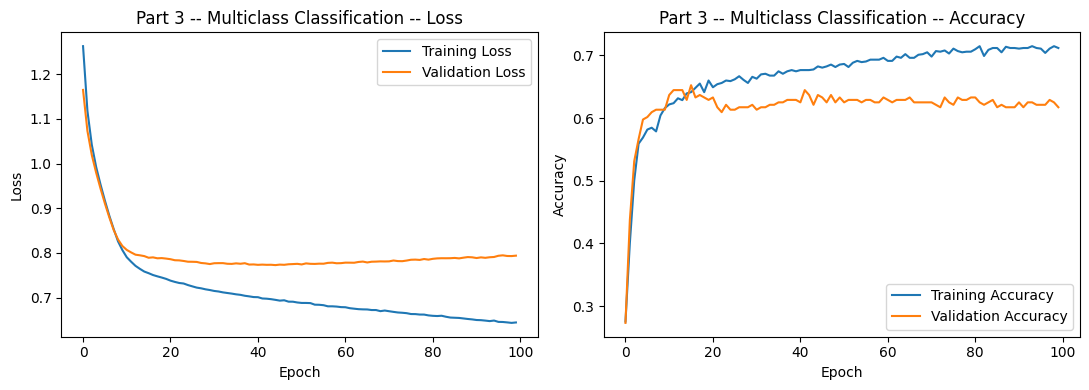

In [ ]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* The model is underfitting by using a 2 layered neural net of 12 neurons in each hidden layer. There is a bit of a gap between the two and they overlap at poor performance layers.


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Part 3 -- Test Accuracy: 0.644


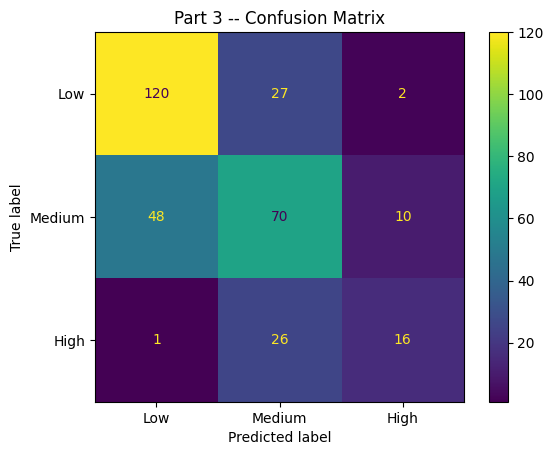

In [ ]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Your answer: This model confuses "medium" with "low" the most often with 42 misclasses total. Yes, this makes sense given how the quality bands were constructed. This is because quality is a continuous spectrum rather than completely distinct categories, the boundary between 'Low' and 'Medium' is likely narrow and arbitrary. The data points near these cutoff thresholds will share highly similar features, making it difficult for the model to perfectly classify "low" and "medium" correctly.

Part B: Hyperparameter Tuning
1. Using Keras Tuner, define a search space of at least 3 hyperparameters.
2. Run the search using training data only. Do not touch your test set during this step.
3. Report the best configuration found and its validation score.
4. Train a final model using that configuration, and evaluate it once on your test set.
5. Compare this result to your original Lab 1 baseline. Did it improve, and by how much?

In [ ]:
def build_model(hp):
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(units=hp.Int("units", min_value=64,  max_value=128, step=32), activation="relu", input_shape=(n_features,)))

  #Adds hidden layers based on num_hidden_layers
  for i in range(hp.Int("num_hidden_layers", min_value = 1, max_value = 3, default=1)):
    model.add(tf.keras.layers.Dense(units=hp.Int(f"units_{i}", min_value=32, max_value=64, step=32), activation="relu"))

  model.add(tf.keras.layers.Dense(n_classes, activation="softmax"))

  model.compile(
  optimizer=tf.keras.optimizers.Adam(
  hp.Choice("learning_rate", [0.01, 0.05, 0.1])
  ),
  loss="sparse_categorical_crossentropy",
  metrics=["accuracy"])
  return model

tuner = kt.RandomSearch(
build_model,
objective="val_loss",
max_trials=10,
overwrite=True
)
tuner.search(
X3_train_scaled, y3_train,
validation_split=0.2, epochs=100, verbose=0
)
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'units': 128, 'num_hidden_layers': 2, 'units_0': 32, 'learning_rate': 0.01, 'units_1': 64}


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Training the best model to get its full history...
Best Model Validation Loss (after 50 epochs): 1.8102
Best Model Validation Accuracy (after 50 epochs): 0.6484

Best Hyperparameters found:
{'units': 128, 'num_hidden_layers': 2, 'units_0': 32, 'learning_rate': 0.01, 'units_1': 64}


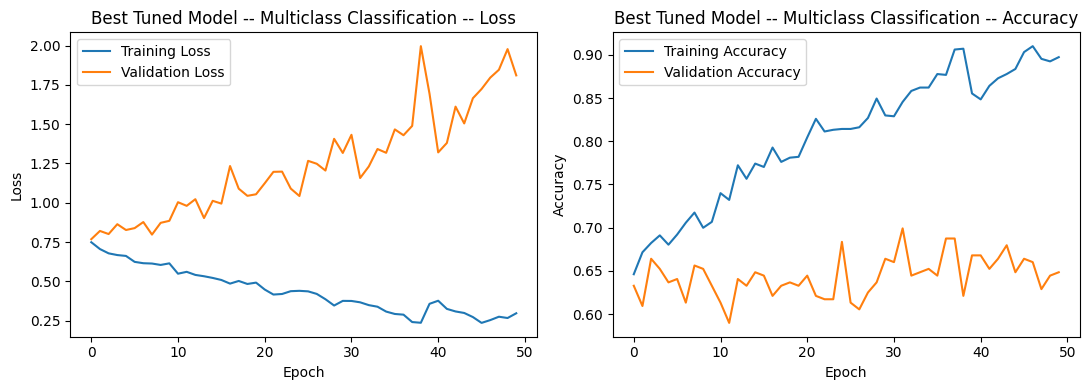

In [ ]:
print("\nTraining the best model to get its full history.")
history_best_model = best_model.fit(
    X3_train_scaled, y3_train, validation_split=0.2, epochs=50, verbose=0
)

# Evaluate on the validation split using the trained history
val_loss = history_best_model.history['val_loss'][-1]
val_accuracy = history_best_model.history['val_accuracy'][-1]

print(f"Best Model Validation Loss (after 50 epochs): {val_loss:.4f}")
print(f"Best Model Validation Accuracy (after 50 epochs): {val_accuracy:.4f}")

print("\nBest Hyperparameters found:")
print(best_hp.values)

plot_history(history_best_model, "Best Tuned Model -- Multiclass Classification", show_accuracy=True)


Evaluating the best model on the test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Best Tuned Model -- Test Accuracy: 0.662


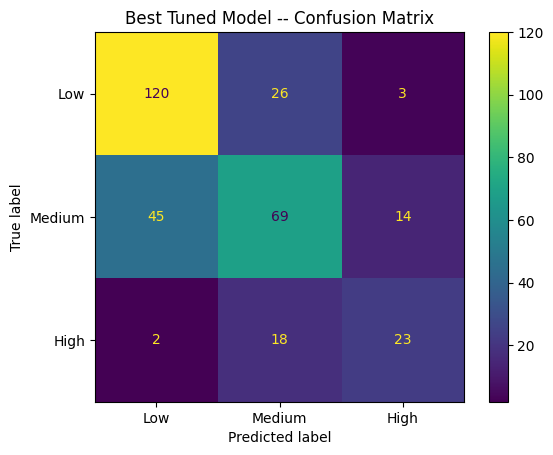

In [ ]:
print('\nEvaluating the best model on the test set...')
best_model_probs = best_model.predict(X3_test_scaled)
best_model_preds = np.argmax(best_model_probs, axis=1)

acc_best_model = accuracy_score(y3_test, best_model_preds)
print(f"Best Tuned Model -- Test Accuracy: {acc_best_model:.3f}")

cm_best_model = confusion_matrix(y3_test, best_model_preds)
ConfusionMatrixDisplay(cm_best_model, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Best Tuned Model -- Confusion Matrix")
plt.show()

In [ ]:
print("\nBest Model Architecture Summary:")
best_model.summary()


Best Model Architecture Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,771 (45.98 KB)

 Trainable params: 3,923 (15.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,848 (30.66 KB)

Compare this result to your original Lab 1 baseline. Did it improve, and by how much: The current model did improve in terms of accuracy for when we apply it to the testing data set with an accuracy of 66.2 which is a 2% increase in accuracy from the original model. However the the current model is very overfitted compared to the original model. With the loss reaching 1.82 compared to the original models loss of 0.8.

Part C: Addressing Overfitting
1. Apply Dropout, Early Stopping, or both to your tuned model from Part B.
2. Retrain, replot the training versus validation loss curve, and compare it directly to your original Lab
1 curve from Part A.
3. Did the gap between training and validation loss shrink? Did validation loss stop rising, or improve
further into training than before?
4. Report your final test accuracy and confusion matrix. Which classes are still being confused most
often, and has that changed from Lab 1?

In [ ]:
#Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
monitor="val_loss",
patience=10,
restore_best_weights=True
)

history = best_model.fit(
X3_train_scaled, y3_train,
validation_split=0.2,
epochs=200,
callbacks=[early_stop],
verbose=0
)



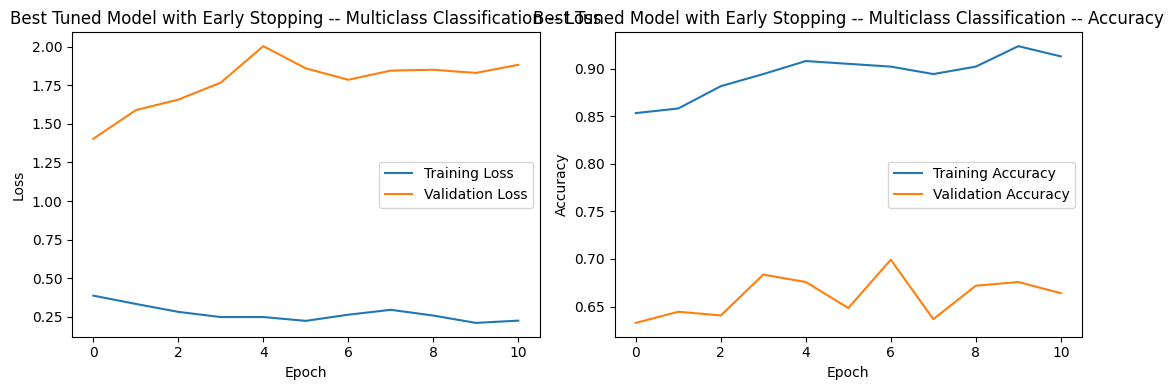

In [ ]:
plot_history(history, "Best Tuned Model with Early Stopping -- Multiclass Classification", show_accuracy=True)

Did the gap between training and validation loss shrink? Did validation loss stop rising, or improve further into training than before: The gap between training and validation increased substantially when we applied early stopping due to the patience applied seemed to stop training after just 10 epochs due to no progress being made from the model. The validation loss had risen since applying the early stopping and dropping of neurons and it seems to increase steadily as the model continued through its training.


Evaluating the model with Early Stopping on the test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Early Stop Model -- Test Accuracy: 0.613


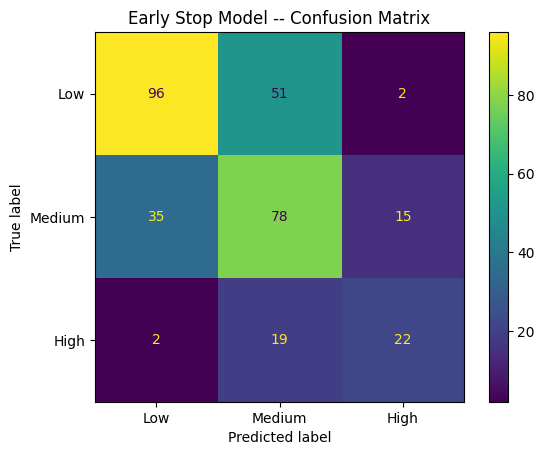

In [ ]:
print('\nEvaluating the model with Early Stopping on the test set...')
early_stop_model_probs = best_model.predict(X3_test_scaled)
early_stop_model_preds = np.argmax(early_stop_model_probs, axis=1)

acc_early_stop_model = accuracy_score(y3_test, early_stop_model_preds)
print(f"Early Stop Model -- Test Accuracy: {acc_early_stop_model:.3f}")

cm_early_stop_model = confusion_matrix(y3_test, early_stop_model_preds)
ConfusionMatrixDisplay(cm_early_stop_model, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Early Stop Model -- Confusion Matrix")
plt.show()

Which classes are still being confused most
often, and has that changed from Lab 1?: The classes still being mostly confused are the "high" quality wines, the confusion matrix did not shift much from the original model and confusion droped by 3% from 64% from the original model to 61.3% to the early stopped model.

Part D: Reflection
1. Why is it important that your test set was touched only once, at the very end?: The test set is reserved for a final unbiased evaluation of the models performance. If we touch the test set any earlier it may cause leaks or inflate results during the evaluation phase.
2. What would have gone wrong if you had used your test set to pick the best hyperparameter: If we had used our test set to pick the best hyperparameters the model's performance would have been great during the evaluation on the testing set however it would have performed very poorly on any other data set.
configuration instead of a validation split?
3. Did Dropout or Early Stopping meaningfully reduce the overfitting you saw in Lab 1? What: When we implemented early stopping, we noticed that it did not reduce overfitting and it seemed that it had actually worsened the accuracy score from 64% to 61.2% and the loss had increased by almost a score of 1.
evidence from your new loss curve supports your answer?
4. If you had unlimited time and compute, what would you try next to improve this model further?: We would try and test a wider array of hyperparameters to achieve the best result. Trying a more indepth range of hidden layers, amount of neurons, and optimizers to see how we can achieve the best result.